# Bank Customer Churn Analysis (SQL + Python)

**Business question:** Which customers are most likely to leave the bank, and what patterns can help the bank improve retention?

**Dataset:** Bank Customer Churn (10,000 customers)

**Tools:** Python, Pandas, SQL (pandasql), Matplotlib, Seaborn

In [20]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction/Churn_Modelling.csv')
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [21]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Data Types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [22]:
from pandasql import sqldf

pysql = lambda q: sqldf(q, globals())

# SQL Query 1 — How many customers churned?
query1 = """
SELECT Exited, COUNT(*) as Total_Customers
FROM df
GROUP BY Exited
"""
result1 = pysql(query1)
print("Customer Churn Count:")
print(result1)

Customer Churn Count:
   Exited  Total_Customers
0       0             7963
1       1             2037


In [23]:
# SQL Query 2 — Churn by Country
query2 = """
SELECT Geography, 
       COUNT(*) as Total_Customers,
       SUM(Exited) as Churned_Customers,
       ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as Churn_Rate_Percent
FROM df
GROUP BY Geography
ORDER BY Churn_Rate_Percent DESC
"""
result2 = pysql(query2)
print("Churn Rate by Country:")
print(result2)

Churn Rate by Country:
  Geography  Total_Customers  Churned_Customers  Churn_Rate_Percent
0   Germany             2509                814               32.44
1     Spain             2477                413               16.67
2    France             5014                810               16.15


In [24]:
# SQL Query 3 — Churn by Gender
query3 = """
SELECT Gender,
       COUNT(*) as Total_Customers,
       SUM(Exited) as Churned_Customers,
       ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as Churn_Rate_Percent
FROM df
GROUP BY Gender
ORDER BY Churn_Rate_Percent DESC
"""
result3 = pysql(query3)
print("Churn Rate by Gender:")
print(result3)

Churn Rate by Gender:
   Gender  Total_Customers  Churned_Customers  Churn_Rate_Percent
0  Female             4543               1139               25.07
1    Male             5457                898               16.46


In [25]:
# SQL Query 4 — Churn by Age Group
query4 = """
SELECT 
    CASE 
        WHEN Age < 30 THEN 'Under 30'
        WHEN Age BETWEEN 30 AND 40 THEN '30-40'
        WHEN Age BETWEEN 41 AND 50 THEN '41-50'
        WHEN Age BETWEEN 51 AND 60 THEN '51-60'
        ELSE 'Above 60'
    END as Age_Group,
    COUNT(*) as Total_Customers,
    SUM(Exited) as Churned_Customers,
    ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as Churn_Rate_Percent
FROM df
GROUP BY Age_Group
ORDER BY Churn_Rate_Percent DESC
"""
result4 = pysql(query4)
print("Churn Rate by Age Group:")
print(result4)

Churn Rate by Age Group:
  Age_Group  Total_Customers  Churned_Customers  Churn_Rate_Percent
0     51-60              797                448               56.21
1     41-50             2320                788               33.97
2  Above 60              464                115               24.78
3     30-40             4778                562               11.76
4  Under 30             1641                124                7.56


In [26]:
# SQL Query 5 — Churn by Number of Products
query5 = """
SELECT NumOfProducts,
       COUNT(*) as Total_Customers,
       SUM(Exited) as Churned_Customers,
       ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as Churn_Rate_Percent
FROM df
GROUP BY NumOfProducts
ORDER BY Churn_Rate_Percent DESC
"""
result5 = pysql(query5)
print("Churn Rate by Number of Products:")
print(result5)

Churn Rate by Number of Products:
   NumOfProducts  Total_Customers  Churned_Customers  Churn_Rate_Percent
0              4               60                 60              100.00
1              3              266                220               82.71
2              1             5084               1409               27.71
3              2             4590                348                7.58


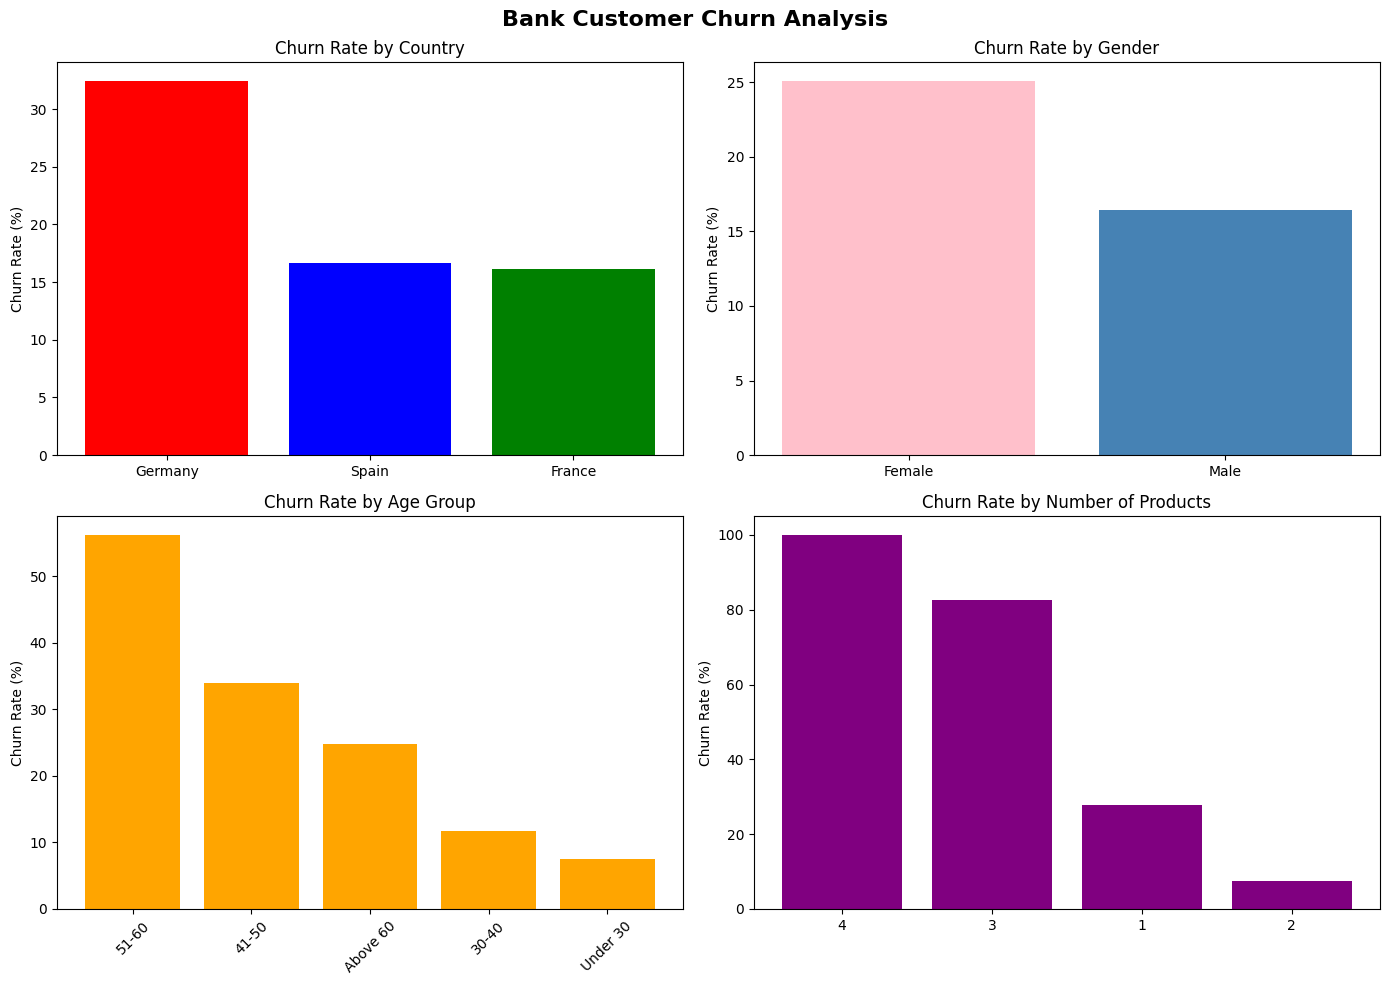

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bank Customer Churn Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Churn by Country
axes[0,0].bar(result2['Geography'], result2['Churn_Rate_Percent'], color=['red','blue','green'])
axes[0,0].set_title('Churn Rate by Country')
axes[0,0].set_ylabel('Churn Rate (%)')

# Chart 2 — Churn by Gender
axes[0,1].bar(result3['Gender'], result3['Churn_Rate_Percent'], color=['pink','steelblue'])
axes[0,1].set_title('Churn Rate by Gender')
axes[0,1].set_ylabel('Churn Rate (%)')

# Chart 3 — Churn by Age Group
axes[1,0].bar(result4['Age_Group'], result4['Churn_Rate_Percent'], color='orange')
axes[1,0].set_title('Churn Rate by Age Group')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 — Churn by Products
axes[1,1].bar(result5['NumOfProducts'].astype(str), result5['Churn_Rate_Percent'], color='purple')
axes[1,1].set_title('Churn Rate by Number of Products')
axes[1,1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

## Bank Customer Churn Analysis — Key Insights

1. Overall 20.37% of customers churned — 2,037 out of 10,000

2. Germany has the highest churn rate at 32.44% — about double that of France (16.15%) and Spain (16.67%)

3. Female customers churn more at 25.07% compared to male customers at 16.46%

4. Customers aged 51-60 have the highest churn rate at 56.21% — more than half leave the bank

5. Customers with 3 or more products churn heavily — 82.71% with 3 products and 100% with 4 products (only 60 customers)

6. Customers with 2 products are the most loyal, with only 7.58% churn